# Beanthentic AI Training Notebook

**Capstone use:** Train Random Forest models, export accuracy metrics, and evaluate the MoP qualitative IPOPHL engine.

**Run Jupyter from the project root** (folder containing `web.py`).

| Section | Trains / evaluates |
|---------|-------------------|
| **A** | Farmer GI readiness (CSV → `gi_model.joblib`) |
| **B** | Document Random Forest (JSON → `gi_document_model.joblib`) |
| **C** | MoP qualitative review (what IPOPHL cards show today) |
| **D** | Deploy + improvement workflow |

In [ ]:
# Cell 1 — Setup paths (run first)
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

# Project root = two levels up from this notebook
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "web.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent.parent / "web.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR  # adjust manually if needed

ML_DIR = PROJECT_ROOT / "machinelearning"
sys.path.insert(0, str(ML_DIR))
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("ML dir:", ML_DIR)

Project root: C:\Users\Eliaza Mae Malibiran\OneDrive - Polytechnic University of the Philippines\Desktop\071626 - BEANTHENTIC\Beanthentic
ML dir: C:\Users\Eliaza Mae Malibiran\OneDrive - Polytechnic University of the Philippines\Desktop\071626 - BEANTHENTIC\Beanthentic\machinelearning


## Section A — Farmer GI readiness (Random Forest)

**Data:** `machinelearning/uploads/beanthentic_synthetic_dataset_1000 (1).csv`  
**Output:** metrics for capstone + optional `gi_model.joblib` via `train_ai_model.py --full-pipeline`

In [ ]:
csv_path = ML_DIR / "uploads" / "beanthentic_synthetic_dataset_1000 (1).csv"
df = pd.read_csv(csv_path)
print("Rows:", len(df), "| Columns:", list(df.columns))

X = df.drop(columns=["gi_ready", "farmer_id"], errors="ignore")
y = df["gi_ready"]
X_enc = pd.get_dummies(X, columns=X.select_dtypes(include=["object"]).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 12, None],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"],
}
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
grid = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
best = grid.best_estimator_
pred = best.predict(X_test)

acc = accuracy_score(y_test, pred)
cv = cross_val_score(best, X_enc, y, cv=5)
print(f"Test accuracy: {acc:.3f}")
print(f"CV mean ± std: {cv.mean():.3f} ± {cv.std():.3f}")
print("Best params:", grid.best_params_)
print(classification_report(y_test, pred, target_names=["Not Ready", "Ready"]))

Rows: 1000 | Columns: ['farmer_id', 'barangay', 'elevation_masl', 'soil_pH', 'annual_rainfall_mm', 'mean_temperature_C', 'coffee_species', 'planting_system', 'farm_ownership', 'rsbsa_registered', 'years_in_farming', 'bearing_trees', 'non_bearing_trees', 'annual_yield_kg', 'processing_method', 'moisture_content_pct', 'defect_count_per_300g', 'selective_picking_practiced', 'farm_records_maintained', 'sales_records_maintained', 'cooperative_member', 'geographic_compliance', 'traditional_method_compliance', 'quality_linkage_documented', 'gi_ready']
Test accuracy: 0.835
CV mean ± std: 0.871 ± 0.019
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

   Not Ready       0.69      0.62      0.65        50
       Ready       0.88      0.91      0.89       150

    accuracy                           0.83       200
   macro avg       0.78      0.76      0.77       200
weighted avg       0.83  

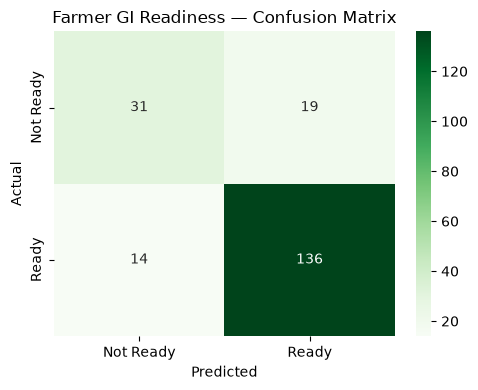

Saved: C:\Users\Eliaza Mae Malibiran\OneDrive - Polytechnic University of the Philippines\Desktop\071626 - BEANTHENTIC\Beanthentic\machinelearning\farmer_confusion_matrix.png


In [ ]:
# Farmer confusion matrix (save figure for capstone)
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Not Ready", "Ready"], yticklabels=["Not Ready", "Ready"])
plt.title("Farmer GI Readiness — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(ML_DIR / "farmer_confusion_matrix.png", dpi=150)
plt.show()
print("Saved:", ML_DIR / "farmer_confusion_matrix.png")

## Section B — IPOPHL document Random Forest

**Production baseline:** official Part 1, Part 2, and Control & Traceability files  
**Training artifacts:** `machinelearning/training_data/ipophl_official_mop_dataset.csv` and `machinelearning/training_data/gi_documents_raw.json`

The IPOPHL module now uses the official MoP qualitative review as the primary judge, with Random Forest as the default validation layer.

**Rebuild + retrain current production model:**
```powershell
python scripts/build_official_mop_dataset.py --train
```

In [ ]:
manifest_path = ML_DIR / "training_data" / "official_mop_manifest.json"
results_path = ML_DIR / "document_training_results.json"
raw_path = ML_DIR / "training_data" / "gi_documents_raw.json"

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
results = json.loads(results_path.read_text(encoding="utf-8"))
dataset = json.loads(raw_path.read_text(encoding="utf-8"))

ready = sum(1 for d in dataset if d.get("label") == "Ready")
not_ready = len(dataset) - ready

print("Official files:", manifest["official_file_count"])
print("Training rows:", manifest["training_row_count"])
print(f"Dataset labels: Ready={ready} | Not Ready={not_ready}")
print(f"Test accuracy: {results['accuracy']:.3f}")
print(f"CV mean ± std: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
print("Best params:", results["best_params"])
print("Analysis method:", results.get("analysis_method"))
print("Training source:", results.get("training_source"))

report = pd.DataFrame(results["classification_report"]).T
report

Documents: 203
Ready: 84 | Not Ready: 119
Test accuracy: 1.000
CV mean ± std: 0.950 ± 0.077
              precision    recall  f1-score   support

   Not Ready       1.00      1.00      1.00        24
       Ready       1.00      1.00      1.00        17

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [ ]:
cm_doc = np.array(results["confusion_matrix"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_doc, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Ready", "Ready"], yticklabels=["Not Ready", "Ready"])
plt.title("Official IPOPHL Document RF — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(ML_DIR / "document_confusion_matrix.png", dpi=150)
plt.show()
print("Saved:", ML_DIR / "document_confusion_matrix.png")
print("Current production metrics:")
print(json.dumps(results, indent=2)[:1200])

## Section C — MoP qualitative engine (production IPOPHL cards)

This is the **authoritative** Ready / Not Ready logic on the dashboard (`gi_reference_basis.py`).  
Use this section to prove accuracy against your real MoP uploads or an expert-labeled test set.

In [ ]:
from config.ipophl_store import OFFICIAL_IPOPHL_TASK_IDS, list_documents, resolve_file_path
from machinelearning.gi_reference_basis import evaluate_against_reference

rows = []
for tid in OFFICIAL_IPOPHL_TASK_IDS:
    docs = list_documents(task_id=tid, limit=5)
    if not docs:
        rows.append({"task_id": tid, "file": "(none)", "status": "—", "word_count": 0})
        continue
    rec = docs[0]
    path = resolve_file_path(rec["file_uuid"], filename_hint=rec.get("original_filename"))
    text = analyzer.extract_text_from_file(str(path)) if path else ""
    review = evaluate_against_reference(text, task_id=tid, term_matches=analyzer._term_matches)
    rows.append({
        "task_id": tid,
        "file": rec.get("original_filename") or path.name,
        "status": review["status"],
        "word_count": review["word_count"],
        "missing": ", ".join(review.get("missing_requirements") or [])[:80],
    })

mop_df = pd.DataFrame(rows)
display(mop_df)
print("Ready count:", (mop_df["status"] == "Ready").sum(), "/", len(OFFICIAL_IPOPHL_TASK_IDS))

### Expert validation (recommended for capstone)

Create `machinelearning/training_data/ipophl_expert_labels.csv`:

```csv
file_uuid,task_id,expected_status,reviewer
88b93a36-...,phase1-introduction,Ready,LGU Reviewer
```

Then compute agreement rate in a new cell:

```python
import csv
labels_path = ML_DIR / "training_data" / "ipophl_expert_labels.csv"
# compare expected_status vs system status → accuracy, confusion matrix
```

## Section D — Deploy models & improve the workflow

### Deploy to production (run in terminal after notebook metrics look good)

```powershell
# Rebuild official IPOPHL MoP dataset + retrain document RF
python scripts\build_official_mop_dataset.py --train

# Re-score stored uploads after model or MoP changes
python scripts\build_document_training_data.py --reanalyze

# Farmer RF (optional, separate workflow)
python machinelearning\train_ai_model.py --full-pipeline

# Restart app
python web.py
```

### Improvement cycle (document in Chapter 3 / Methodology)

1. Update the official Part 1 / Part 2 / Control documents or their labels  
2. Rebuild the official dataset and retrain the RF validator  
3. Check notebook metrics and confusion matrix  
4. Reanalyze stored IPOPHL uploads  
5. Export JSON metrics and figures for the paper  

Full written guide: `docs/JUPYTER_ML_TRAINING_GUIDE.md`

In [ ]:
# Optional: deploy document model from this notebook (uncomment to run)
# import joblib
# joblib.dump(doc_rf, ML_DIR / "gi_document_model.joblib")
# print("Saved gi_document_model.joblib — restart web.py")

# Check what the live app will report
status_path = ML_DIR / "document_training_results.json"
if status_path.exists():
    print("Current production document metrics:")
    print(json.dumps(json.loads(status_path.read_text(encoding="utf-8")), indent=2)[:1200])